# About Dataset
source : https://archive.ics.uci.edu/dataset/45/heart+disease
Only 14 attributes used:
1. #3  (age)       
2. #4  (sex)       
3. #9  (cp)        
4. #10 (trestbps)  
5. #12 (chol)      
6. #16 (fbs)       
7. #19 (restecg)   
8. #32 (thalach)   
9. #38 (exang)     
10. #40 (oldpeak)   
11. #41 (slope)     
12. #44 (ca)        
13. #51 (thal)      
14. #58 (num)       (the predicted attribute)

Complete attribute documentation:
1.     3 age: age in years
2.     4 sex: sex (1 = male; 0 = female)
3.    9 cp: chest pain type
        -- Value 1: typical angina
        -- Value 2: atypical angina
        -- Value 3: non-anginal pain
        -- Value 4: asymptomatic
 4.    10 trestbps: resting blood pressure (in mm Hg on admission to the hospital)
 5.    12 chol: serum cholestoral in mg/dl
 6.   16 fbs: (fasting blood sugar > 120 mg/dl)  (1 = true; 0 = false)
7.   32 thalach: maximum heart rate achieved
8.    38 exang: exercise induced angina (1 = yes; 0 = no)
9.   40 oldpeak = ST depression induced by exercise relative to rest
10.      41 slope: the slope of the peak exercise ST segment
        -- Value 1: upsloping
        -- Value 2: flat
        -- Value 3: downsloping
 11.    44 ca: number of major vessels (0-3) colored by flourosopy
 12.    51 thal: 3 = normal; 6 = fixed defect; 7 = reversable defect
 13.    58 num: diagnosis of heart disease (angiographic disease status)
        -- Value 0: < 50% diameter narrowing
        -- Value 1: > 50% diameter narrowing
        (in any major vessel: attributes 59 through 68 are vessels)

### versi lebih mudah

Kolom    Artinya secara gampang
age=    Umur pasien
sex=    Jenis kelamin
cp=    Tipe nyeri dada (chest pain)
trestbps=    Tekanan darah saat istirahat
chol=    Kadar kolesterol
fbs=    Apakah gula darah puasa >120 mg/dL
restecg=    Hasil ECG saat istirahat
thalach=    Detak jantung maksimum yang tercapai
exang=    Apakah olahraga memicu angina/nyeri dada
oldpeak=    Penurunan segmen ST akibat olahraga dibanding istirahat
slope=    Bentuk/kemiringan segmen ST saat puncak olahraga
ca=    Jumlah pembuluh darah utama yang terlihat melalui fluoroskopi
thal=    Hasil pemeriksaan terkait thalassemia/perfusi jantung
target    Label: ada/tidak penyakit jantung

In [1]:
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt


In [2]:
data = pd.read_csv("heart_disease_dataset.csv")
data

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


In [3]:
data.info()
data.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


### notes
1. Tidak ada missing value pada semua fitur
2. Pasien paling parah cp nya di Value 3 (non anginal pain)
3. Restecg kemungkinan besar bersifat kategorikal
4. Oldpeak rangenya tidak jauh
5. Slope hanya mencapai Flat saja
6. Ca seharusnya sampai 3 saja, tapi max ada di 4
7. Value thal di verifikasi ulang nanti

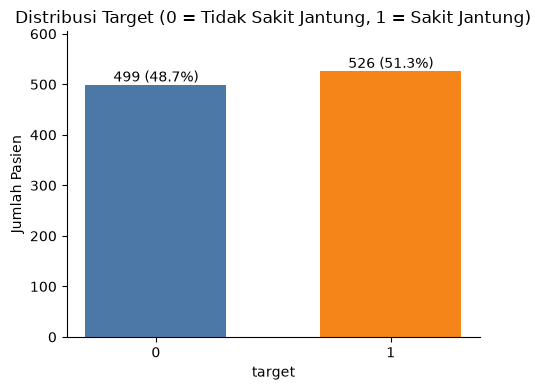

target
1    526
0    499
Name: count, dtype: int64
target
1    0.5132
0    0.4868
Name: proportion, dtype: float64


In [4]:
counts = data['target'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(counts.index.astype(str), counts.values,
              color=['#4C78A8', '#F58518'], width=0.6)

# label jumlah + persentase di atas tiap batang
total = counts.sum()
for bar, v in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, v,
            f'{v} ({v/total:.1%})', ha='center', va='bottom', fontsize=10)

ax.set_title('Distribusi Target (0 = Tidak Sakit Jantung, 1 = Sakit Jantung)')
ax.set_xlabel('target')
ax.set_ylabel('Jumlah Pasien')
ax.set_ylim(0, counts.max() * 1.15)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

print(data['target'].value_counts())
print(data['target'].value_counts(normalize=True).round(4))


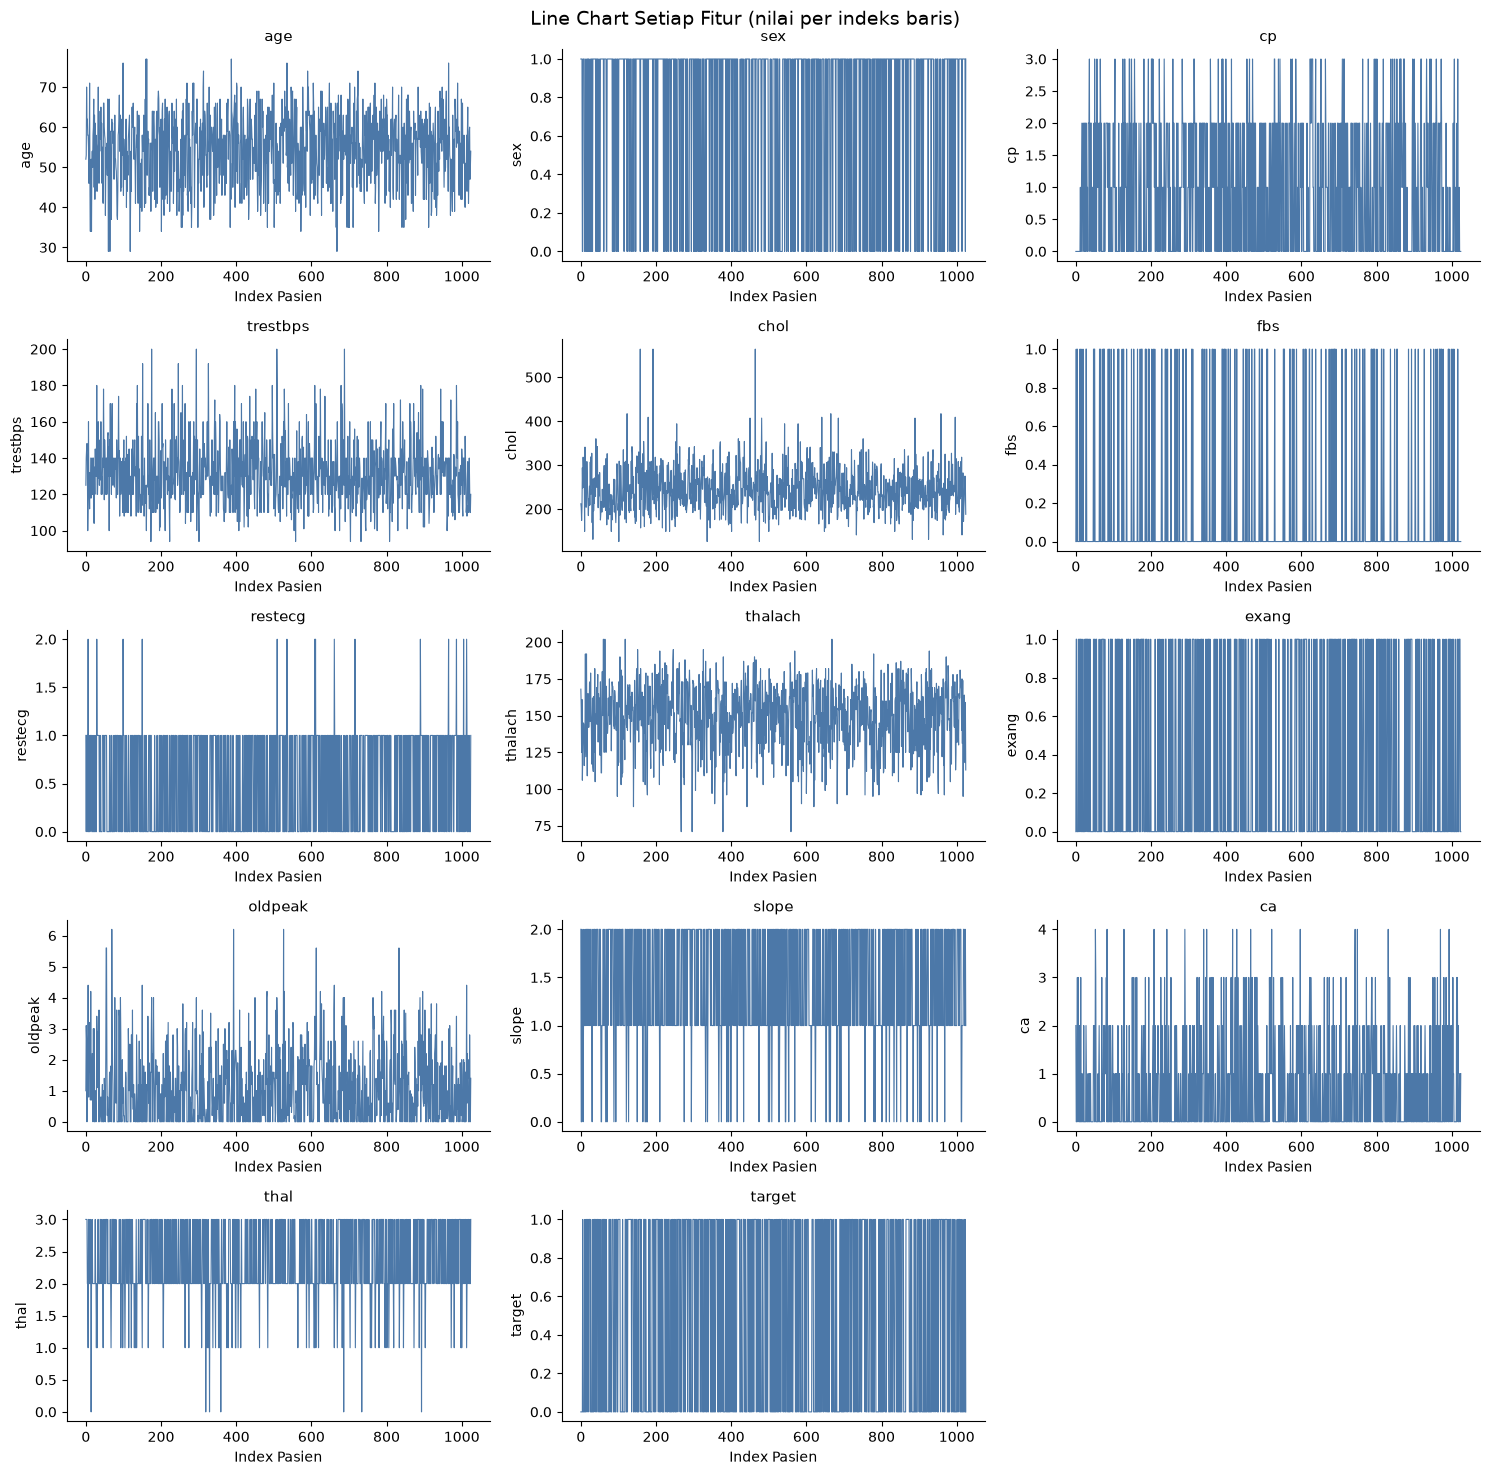

In [5]:
# guard: pastikan `data` tetap DataFrame (pernah tertimpa jadi Series -> KeyError 'target')
if not isinstance(globals().get("data"), pd.DataFrame):
    data = pd.read_csv("heart_disease_dataset.csv")

cols  = data.select_dtypes(include=np.number).columns.tolist()   # hanya kolom numerik
n     = len(cols)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3 * nrows))
axes = np.atleast_1d(axes).ravel()        # aman walau grid 1x1 / 1 baris

for ax, col in zip(axes, cols):
    ax.plot(data.index, data[col], color='#4C78A8', linewidth=0.8)
    ax.set_title(col, fontsize=11)
    ax.set_xlabel('Index Pasien')
    ax.set_ylabel(col)
    for sisi in ('top', 'right'):          # kompatibel semua versi matplotlib
        ax.spines[sisi].set_visible(False)

for ax in axes[n:]:                        # matikan subplot sisa
    ax.set_visible(False)

fig.suptitle('Line Chart Setiap Fitur (nilai per indeks baris)', fontsize=14)
plt.tight_layout()
plt.show()

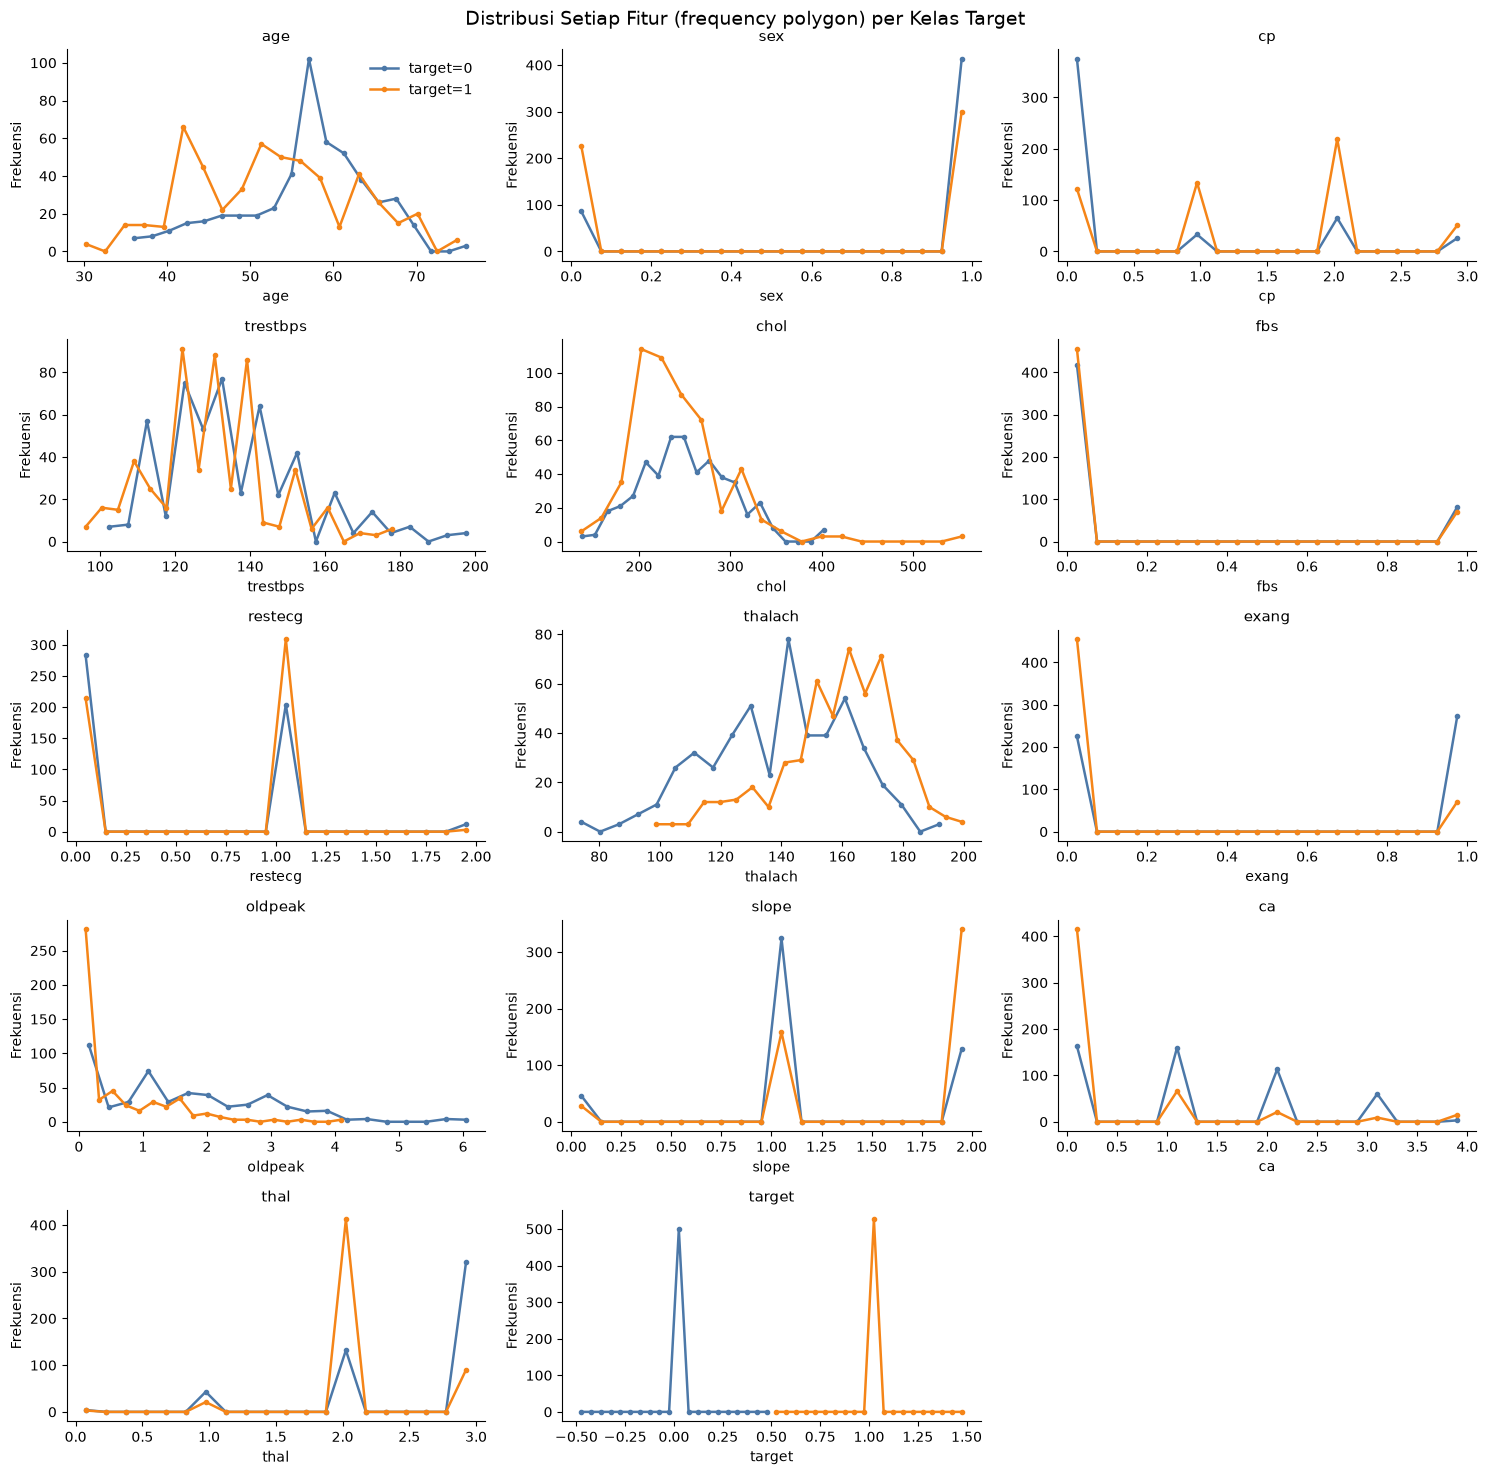

In [6]:
# guard: pastikan `data` tetap DataFrame (pernah tertimpa jadi Series -> KeyError 'target')
if not isinstance(globals().get("data"), pd.DataFrame):
    data = pd.read_csv("heart_disease_dataset.csv")

cols  = data.select_dtypes(include=np.number).columns.tolist()
n     = len(cols)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3 * nrows))
axes = np.atleast_1d(axes).ravel()

for ax, col in zip(axes, cols):
    for t, warna in zip([0, 1], ['#4C78A8', '#F58518']):
        subset = data.loc[data['target'] == t, col].dropna()
        if subset.empty:
            continue
        freq, edges = np.histogram(subset, bins=20)
        centers = (edges[:-1] + edges[1:]) / 2
        ax.plot(centers, freq, color=warna, linewidth=1.8,
                marker='o', markersize=3, label=f'target={t}')
    ax.set_title(col, fontsize=11)
    ax.set_xlabel(col)
    ax.set_ylabel('Frekuensi')
    for sisi in ('top', 'right'):
        ax.spines[sisi].set_visible(False)

for ax in axes[n:]:
    ax.set_visible(False)

axes[0].legend(frameon=False)
fig.suptitle('Distribusi Setiap Fitur (frequency polygon) per Kelas Target', fontsize=14)
plt.tight_layout()
plt.show()

### notes
1. Yang kategorikal adalah sex, cp, fbs, exang, slope, ca, thal, target

## Scatter Plot Setiap Fitur

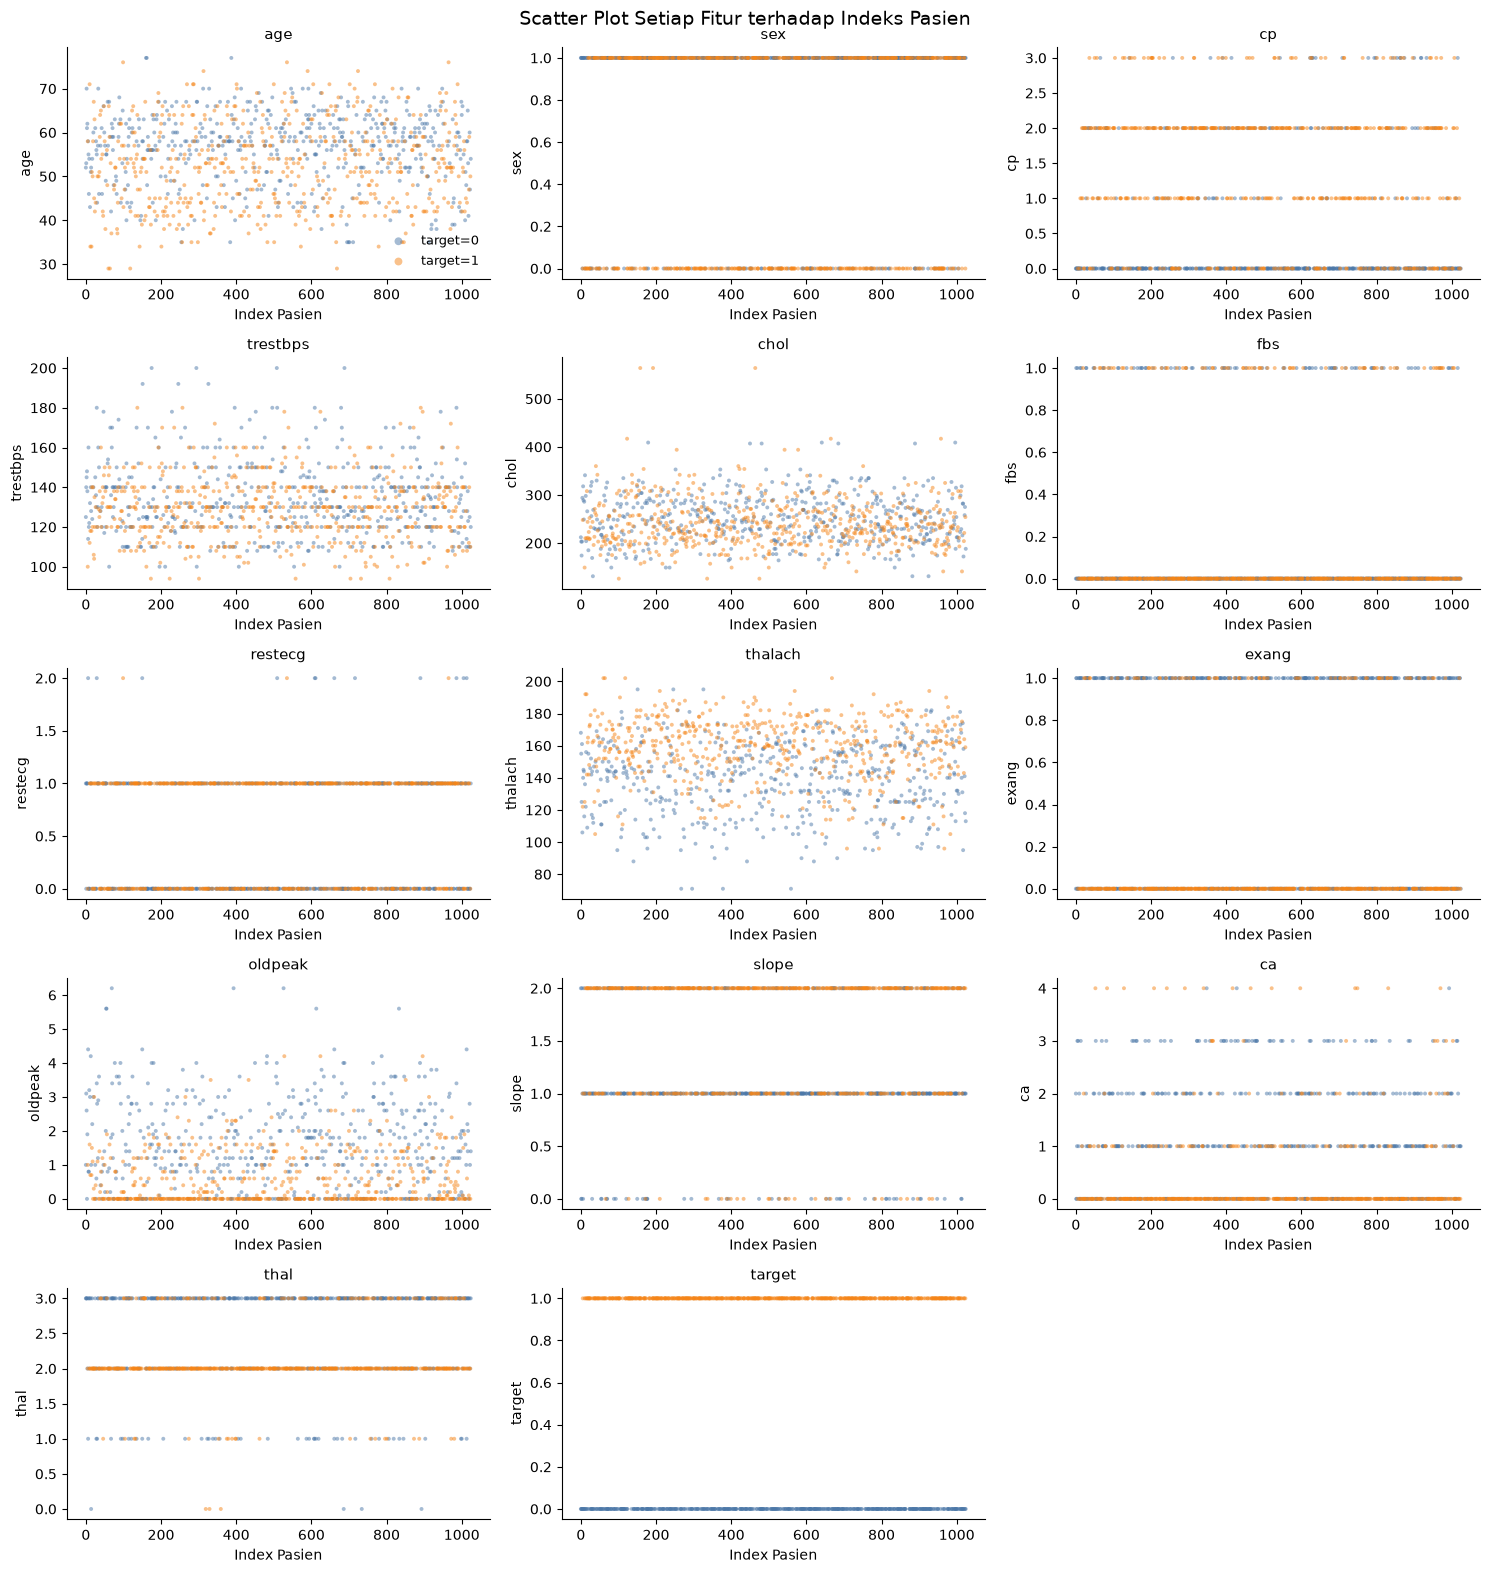

In [7]:
# guard: pastikan `data` tetap DataFrame
if not isinstance(globals().get("data"), pd.DataFrame):
    data = pd.read_csv("heart_disease_dataset.csv")

# scatter tiap fitur terhadap indeks pasien, diwarnai kelas target
cols  = data.select_dtypes(include=np.number).columns.tolist()
n     = len(cols)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3.2 * nrows))
axes = np.atleast_1d(axes).ravel()

for ax, col in zip(axes, cols):
    for t, warna in zip([0, 1], ['#4C78A8', '#F58518']):
        subset = data[data['target'] == t]
        ax.scatter(subset.index, subset[col], s=8, alpha=0.5,
                   color=warna, edgecolors='none', label=f'target={t}')
    ax.set_title(col, fontsize=11)
    ax.set_xlabel('Index Pasien')
    ax.set_ylabel(col)
    for sisi in ('top', 'right'):
        ax.spines[sisi].set_visible(False)

for ax in axes[n:]:
    ax.set_visible(False)

axes[0].legend(frameon=False, markerscale=2, fontsize=9)
fig.suptitle('Scatter Plot Setiap Fitur terhadap Indeks Pasien', fontsize=14)
plt.tight_layout()
plt.show()

1. thal = 2 menghasilkan target 1 yang cukup banyak
2. fbs = di value 0 banyak target 1
3. slope = value 2 banyak target 1
4. exang = value 0 banyak trget 1
5. ca = value 0 banyak target 1
6. restecg ambigu untuk diliat manual

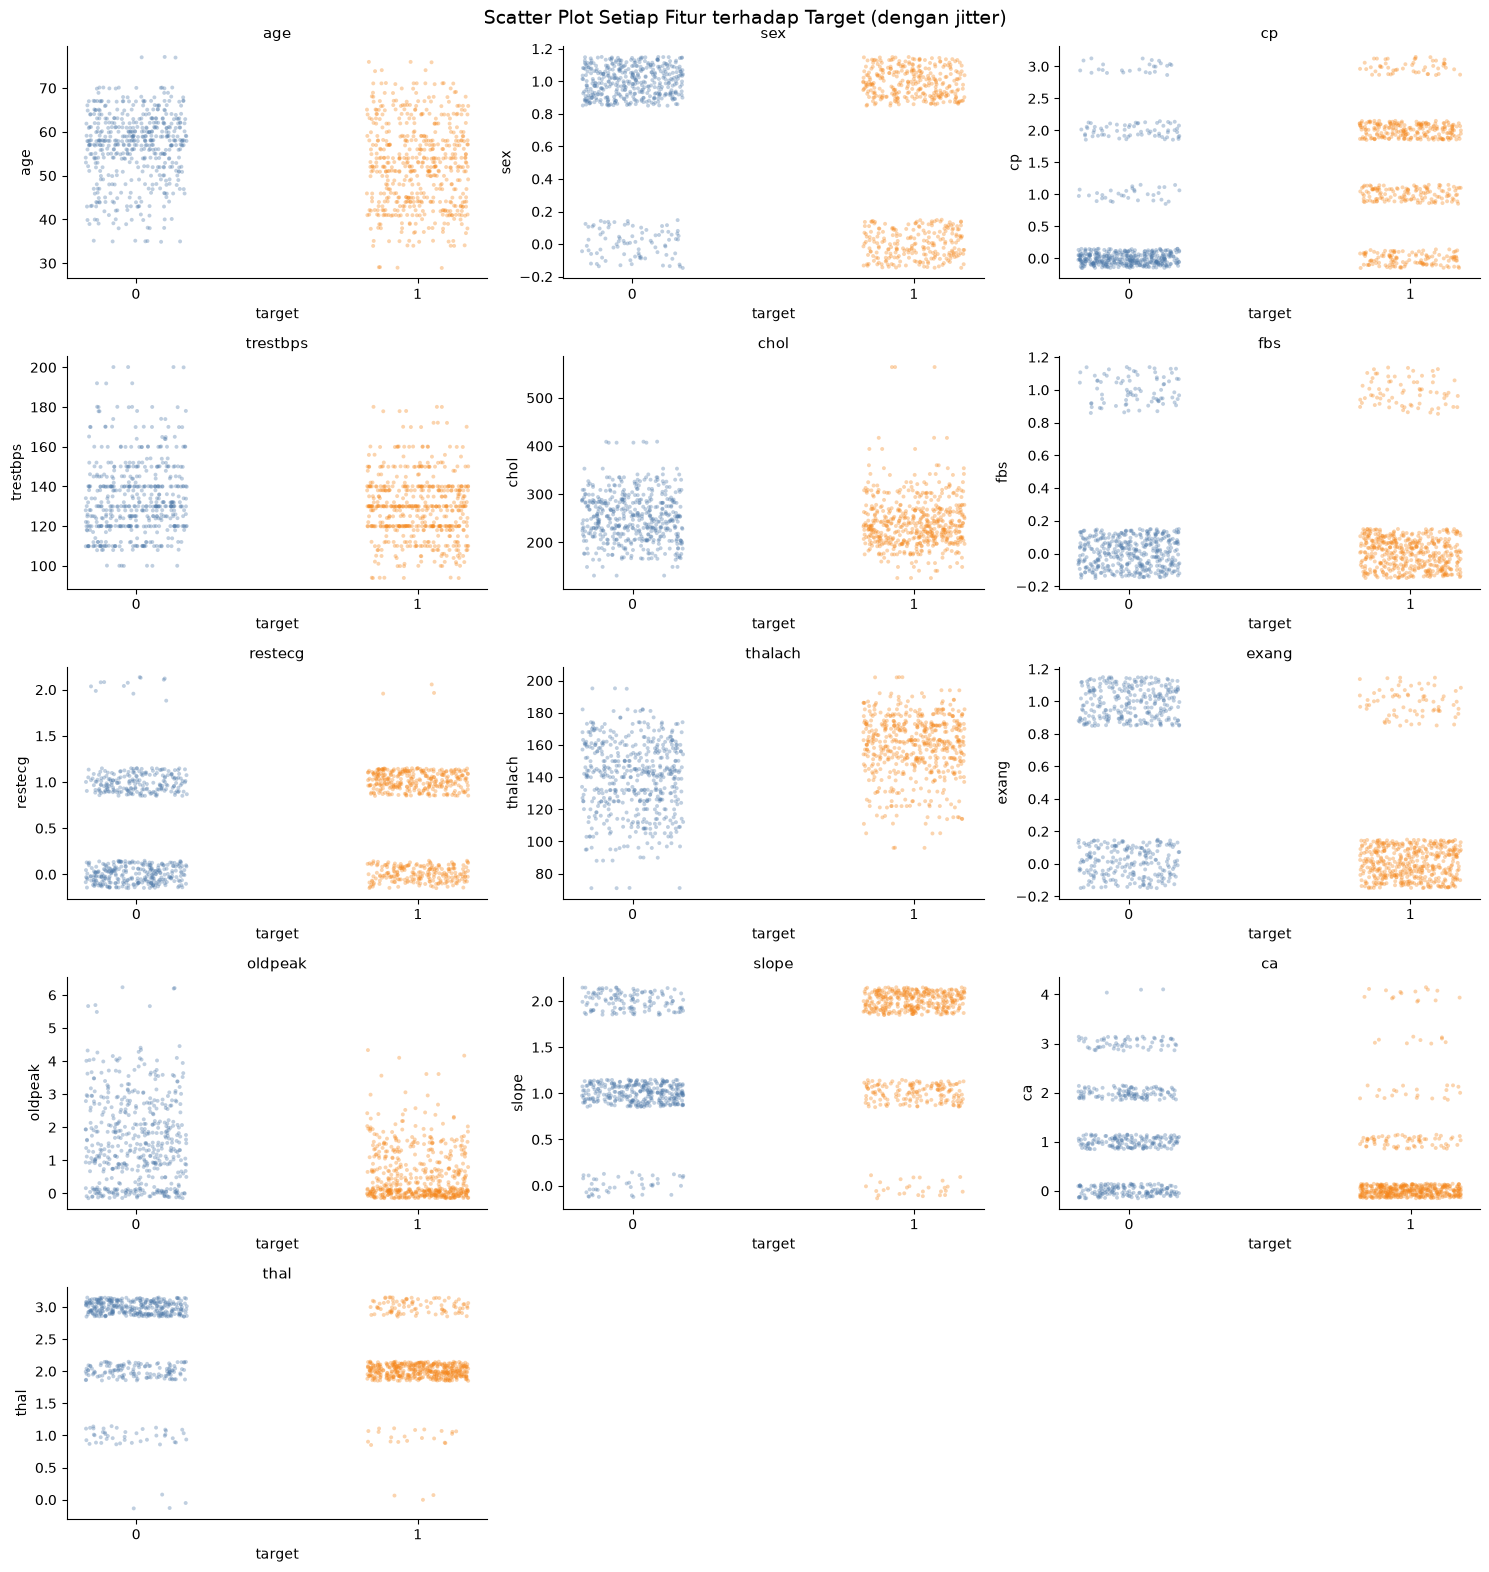

In [8]:
# guard: pastikan `data` tetap DataFrame
if not isinstance(globals().get("data"), pd.DataFrame):
    data = pd.read_csv("heart_disease_dataset.csv")

# scatter tiap fitur terhadap target, pakai jitter supaya titik tidak saling menimpa
cols  = [c for c in data.select_dtypes(include=np.number).columns if c != 'target']
n     = len(cols)
ncols = 3
nrows = int(np.ceil(n / ncols))

rng = np.random.default_rng(42)

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3.2 * nrows))
axes = np.atleast_1d(axes).ravel()

for ax, col in zip(axes, cols):
    for t, warna in zip([0, 1], ['#4C78A8', '#F58518']):
        subset = data[data['target'] == t]
        x = t + rng.uniform(-0.18, 0.18, size=len(subset))
        y = subset[col] + rng.uniform(-0.15, 0.15, size=len(subset))
        ax.scatter(x, y, s=8, alpha=0.35, color=warna, edgecolors='none')
    ax.set_xticks([0, 1])
    ax.set_title(col, fontsize=11)
    ax.set_xlabel('target')
    ax.set_ylabel(col)
    for sisi in ('top', 'right'):
        ax.spines[sisi].set_visible(False)

for ax in axes[n:]:
    ax.set_visible(False)

fig.suptitle('Scatter Plot Setiap Fitur terhadap Target (dengan jitter)', fontsize=14)
plt.tight_layout()
plt.show()

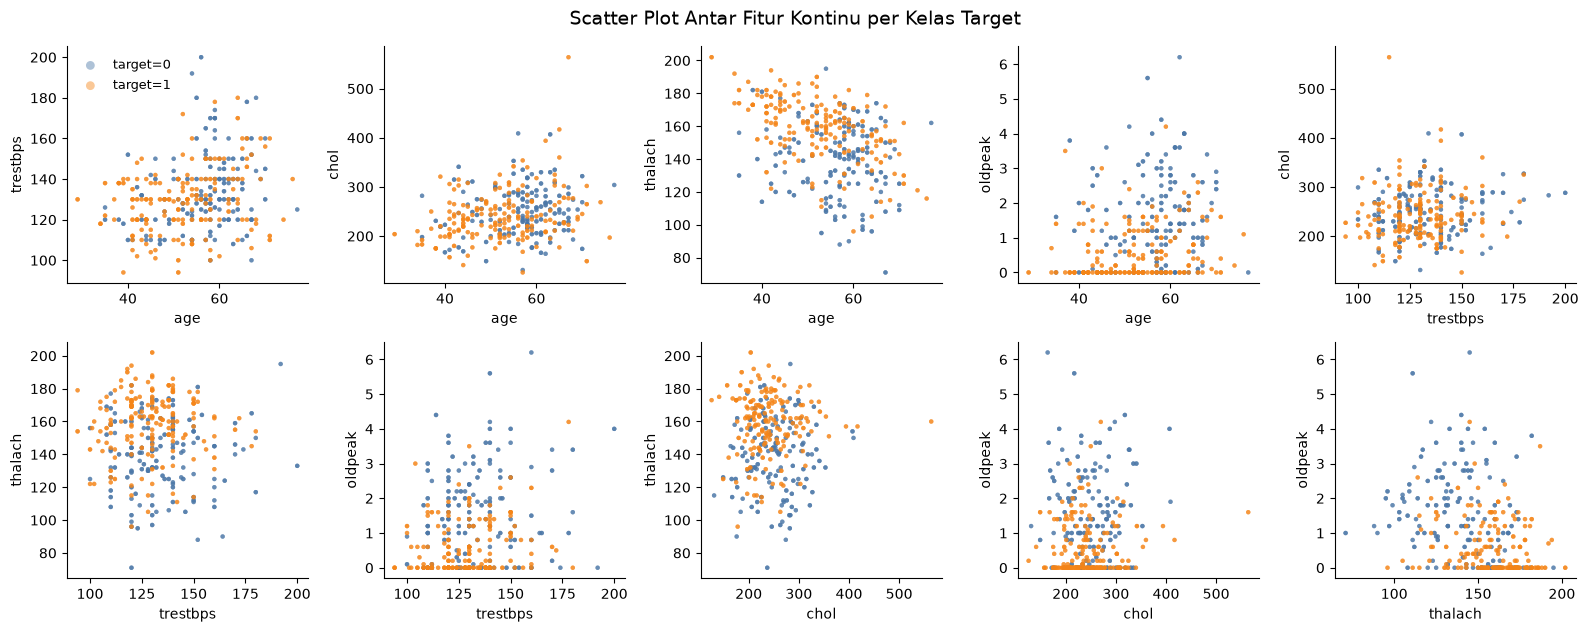

In [9]:
# guard: pastikan `data` tetap DataFrame
if not isinstance(globals().get("data"), pd.DataFrame):
    data = pd.read_csv("heart_disease_dataset.csv")

# scatter antar pasangan fitur kontinu, diwarnai kelas target
kontinu = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

pasangan = [(a, b) for i, a in enumerate(kontinu) for b in kontinu[i + 1:]]
n     = len(pasangan)
ncols = 5
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3.2 * nrows))
axes = np.atleast_1d(axes).ravel()

for ax, (x_col, y_col) in zip(axes, pasangan):
    for t, warna in zip([0, 1], ['#4C78A8', '#F58518']):
        subset = data[data['target'] == t]
        ax.scatter(subset[x_col], subset[y_col], s=10, alpha=0.45,
                   color=warna, edgecolors='none', label=f'target={t}')
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    for sisi in ('top', 'right'):
        ax.spines[sisi].set_visible(False)

for ax in axes[n:]:
    ax.set_visible(False)

axes[0].legend(frameon=False, markerscale=2, fontsize=9)
fig.suptitle('Scatter Plot Antar Fitur Kontinu per Kelas Target', fontsize=14)
plt.tight_layout()
plt.show()

### notes scatter
1. Scatter terhadap indeks pasien memperlihatkan sebaran nilai sekaligus memisahkan warna per kelas target - berguna untuk melihat apakah data terurut atau ada pola aneh pada urutan baris
2. Fitur kategorik akan tampak sebagai garis-garis titik horizontal karena nilainya hanya 0-3; itu wajar, bukan error
3. Scatter terhadap target memakai jitter agar titik yang bertumpuk terlihat kepadatannya
4. Scatter antar fitur kontinu paling informatif: cari pemisahan warna, misalnya thalach tinggi lebih banyak di target=1, sedangkan oldpeak tinggi lebih banyak di target=0

## Korelasi Antar Fitur: Pearson vs Spearman

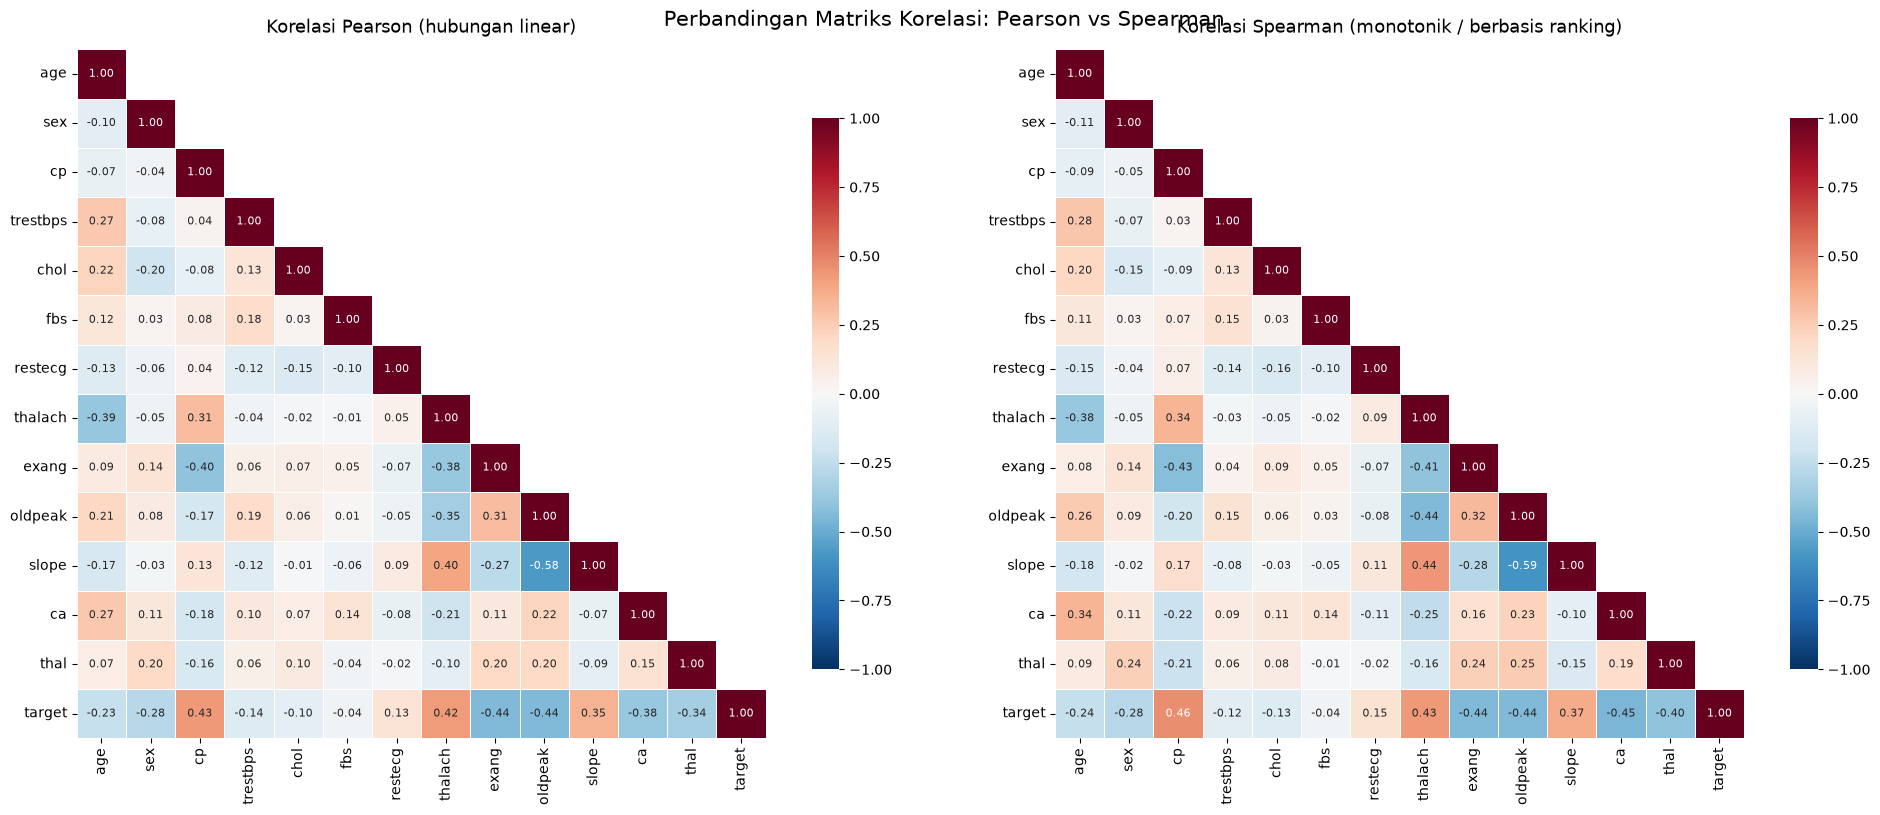

In [10]:
# guard: pastikan `data` tetap DataFrame (pernah tertimpa jadi Series -> KeyError 'target')
if not isinstance(globals().get("data"), pd.DataFrame):
    data = pd.read_csv("heart_disease_dataset.csv")

corr_pearson  = data.corr(method='pearson',  numeric_only=True)
corr_spearman = data.corr(method='spearman', numeric_only=True)

mask = np.triu(np.ones_like(corr_pearson, dtype=bool), k=1)   # sembunyikan segitiga atas

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

for ax, corr, judul in zip(axes,
                           [corr_pearson, corr_spearman],
                           ['Pearson (hubungan linear)',
                            'Spearman (monotonik / berbasis ranking)']):
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
                vmin=-1, vmax=1, center=0, square=True, linewidths=0.5,
                cbar_kws={'shrink': 0.8}, annot_kws={'size': 8}, ax=ax)
    ax.set_title(f'Korelasi {judul}', fontsize=13, pad=12)

fig.suptitle('Perbandingan Matriks Korelasi: Pearson vs Spearman', fontsize=15)
plt.tight_layout()
plt.show()

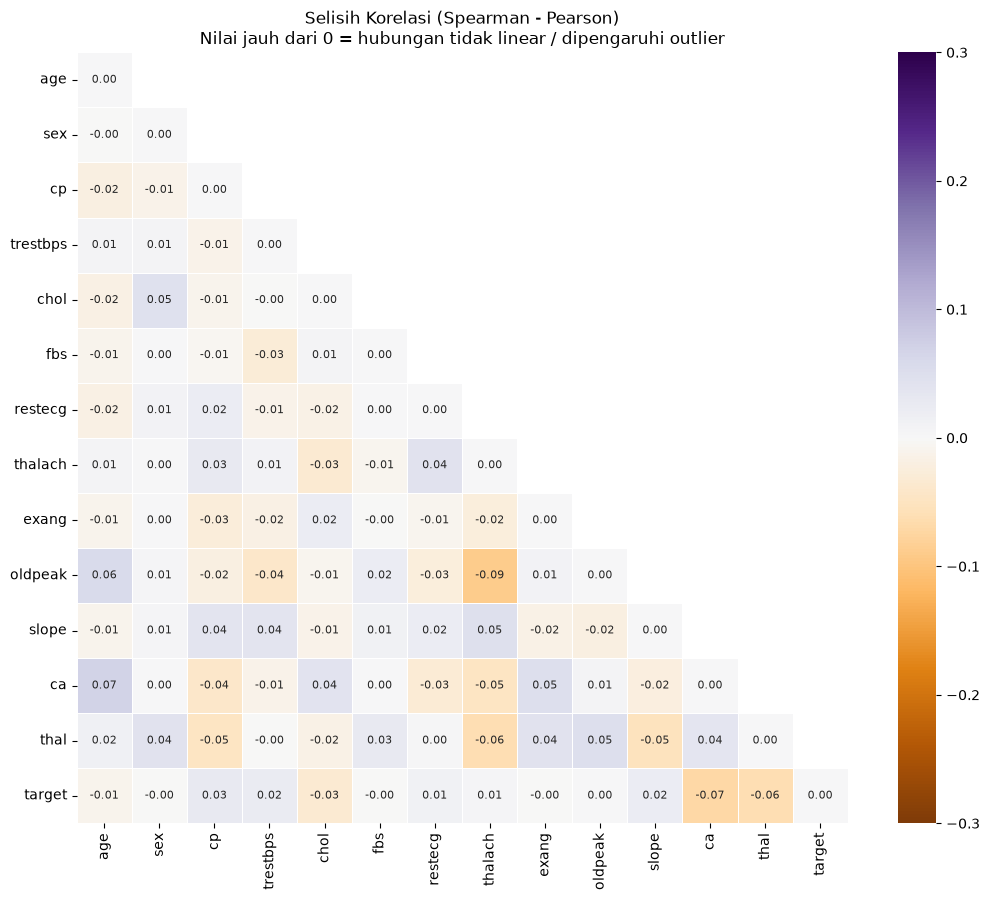

In [11]:
diff = corr_spearman - corr_pearson

plt.figure(figsize=(11, 9))
sns.heatmap(diff, mask=mask, annot=True, fmt='.2f', cmap='PuOr',
            center=0, vmin=-0.3, vmax=0.3, square=True,
            linewidths=0.5, annot_kws={'size': 8})
plt.title('Selisih Korelasi (Spearman - Pearson)\n'
          'Nilai jauh dari 0 = hubungan tidak linear / dipengaruhi outlier', fontsize=12)
plt.tight_layout()
plt.show()

In [12]:
# ambil segitiga bawah saja supaya tiap pasangan fitur muncul sekali
tril = np.tril(np.ones(corr_pearson.shape), k=-1).astype(bool)

pairs = corr_pearson.where(tril).stack().rename('pearson').to_frame()
pairs['spearman']    = corr_spearman.where(tril).stack()
pairs['selisih']     = pairs['spearman'] - pairs['pearson']
pairs['abs_selisih'] = pairs['selisih'].abs()

perbandingan = (pairs.sort_values('abs_selisih', ascending=False)
                     .round(3)
                     .reset_index()
                     .rename(columns={'level_0': 'fitur_1', 'level_1': 'fitur_2'}))

print('=== 10 pasangan dengan perbedaan Pearson vs Spearman terbesar ===')
print(perbandingan.head(10).to_string(index=False))

target_corr = pd.DataFrame({
    'pearson':  corr_pearson['target'],
    'spearman': corr_spearman['target'],
}).drop(index='target')
target_corr['selisih'] = target_corr['spearman'] - target_corr['pearson']

print('\n=== Korelasi setiap fitur terhadap target ===')
print(target_corr.round(3)
                 .sort_values('spearman', key=abs, ascending=False)
                 .to_string())

=== 10 pasangan dengan perbedaan Pearson vs Spearman terbesar ===
fitur_1 fitur_2  pearson  spearman  selisih  abs_selisih
oldpeak thalach   -0.350    -0.440   -0.090        0.090
 target      ca   -0.382    -0.453   -0.071        0.071
     ca     age    0.272     0.340    0.068        0.068
 target    thal   -0.338    -0.399   -0.061        0.061
   thal thalach   -0.098    -0.159   -0.061        0.061
oldpeak     age    0.208     0.265    0.056        0.056
   thal   slope   -0.094    -0.146   -0.052        0.052
     ca   exang    0.108     0.159    0.051        0.051
   thal oldpeak    0.203     0.253    0.051        0.051
   thal      cp   -0.163    -0.212   -0.049        0.049

=== Korelasi setiap fitur terhadap target ===
          pearson  spearman  selisih
cp          0.435     0.465    0.030
ca         -0.382    -0.453   -0.071
exang      -0.438    -0.438   -0.000
oldpeak    -0.438    -0.438    0.001
thalach     0.423     0.430    0.007
thal       -0.338    -0.399   -0.061
s

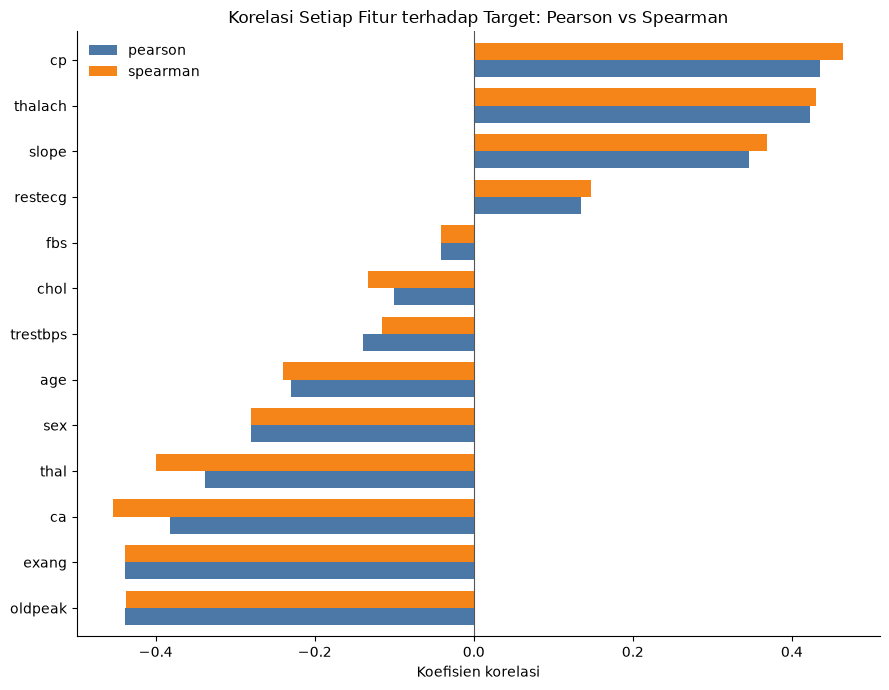

In [13]:
plot_df = target_corr.sort_values('pearson')[['pearson', 'spearman']]

ax = plot_df.plot(kind='barh', figsize=(9, 7),
                  color=['#4C78A8', '#F58518'], width=0.75)
ax.axvline(0, color='#555', linewidth=0.8)
ax.set_title('Korelasi Setiap Fitur terhadap Target: Pearson vs Spearman')
ax.set_xlabel('Koefisien korelasi')
ax.legend(frameon=False)
for sisi in ('top', 'right'):
    ax.spines[sisi].set_visible(False)
plt.tight_layout()
plt.show()

### notes korelasi
1. Pearson mengukur hubungan linear, cocok untuk fitur numerik kontinu (age, trestbps, chol, thalach, oldpeak)
2. Spearman berbasis ranking, lebih tahan outlier dan lebih tepat untuk fitur ordinal (cp, slope, ca, thal)
3. Untuk fitur biner (sex, fbs, exang, target) kedua nilai akan mirip dan setara point-biserial
4. Selisih besar pada heatmap Spearman - Pearson = penanda hubungan non-linear atau pengaruh outlier

## Deteksi Outlier dengan Box Plot

C:\Users\airal\AppData\Local\Temp\ipykernel_37388\544756455.py:14: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(data[col].dropna(), vert=True, widths=0.5,
C:\Users\airal\AppData\Local\Temp\ipykernel_37388\544756455.py:14: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(data[col].dropna(), vert=True, widths=0.5,
C:\Users\airal\AppData\Local\Temp\ipykernel_37388\544756455.py:14: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(data[col].dropna(), vert=True, widths=0.5,
C:\Users\airal\AppData\Local\Temp\ipykernel_37388\544756455.py:14: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be remove

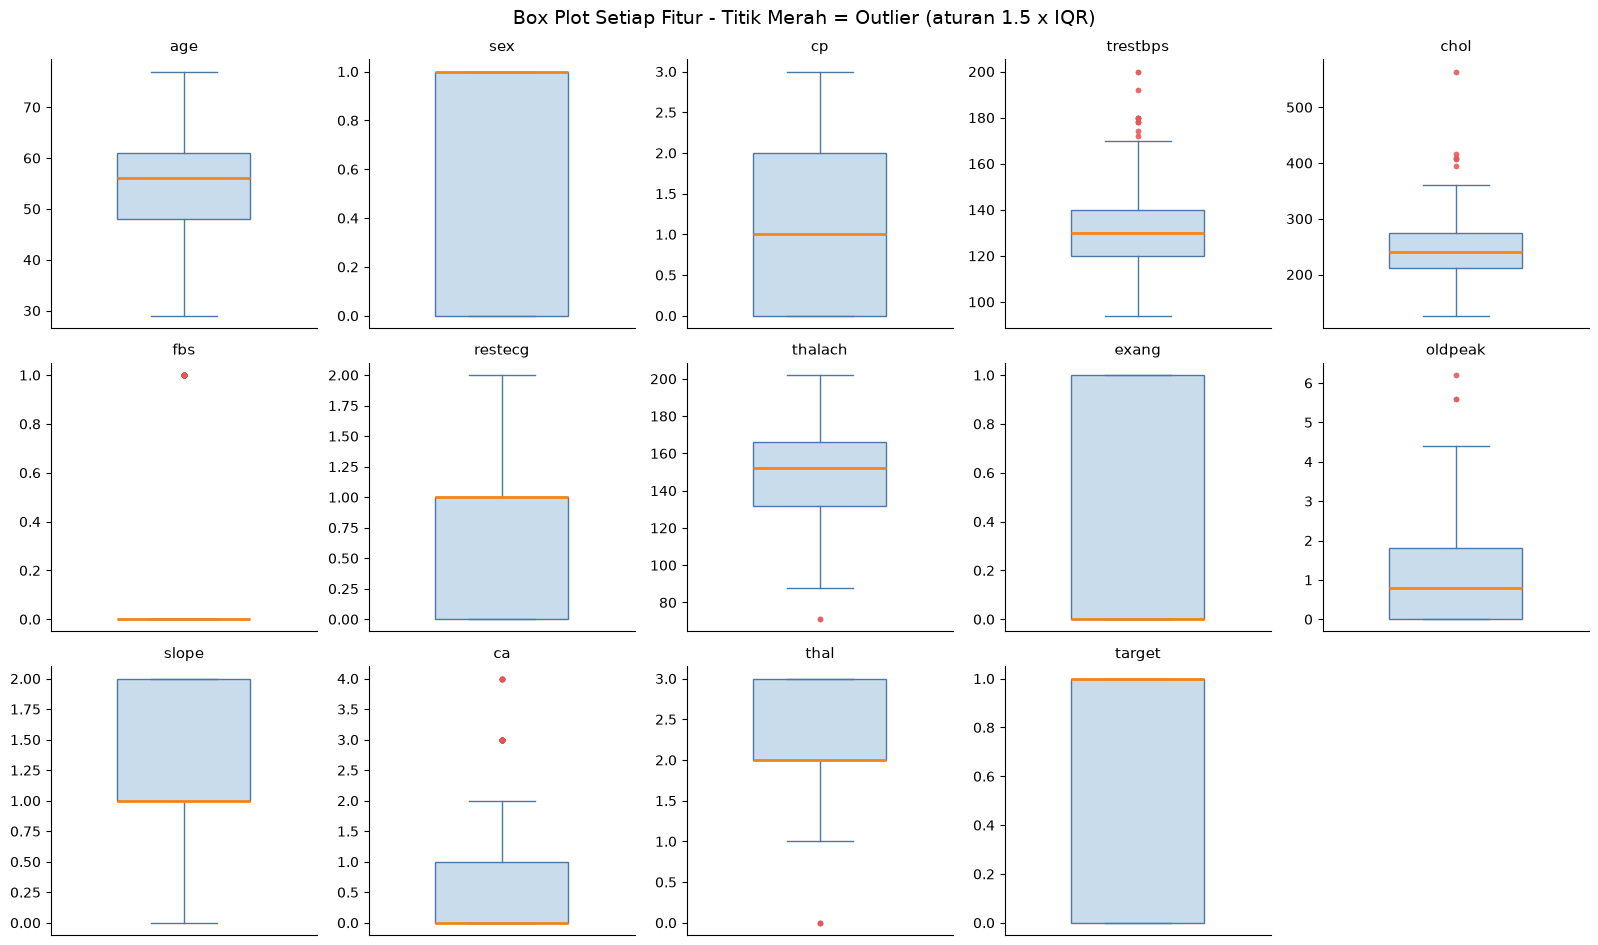

In [14]:
# guard: pastikan `data` tetap DataFrame
if not isinstance(globals().get("data"), pd.DataFrame):
    data = pd.read_csv("heart_disease_dataset.csv")

cols  = data.select_dtypes(include=np.number).columns.tolist()
n     = len(cols)
ncols = 5
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3.2 * nrows))
axes = np.atleast_1d(axes).ravel()

for ax, col in zip(axes, cols):
    ax.boxplot(data[col].dropna(), vert=True, widths=0.5,
               patch_artist=True,
               boxprops=dict(facecolor='#C9DCEC', edgecolor='#4C78A8'),
               medianprops=dict(color='#F58518', linewidth=2),
               whiskerprops=dict(color='#4C78A8'),
               capprops=dict(color='#4C78A8'),
               flierprops=dict(marker='o', markersize=4,
                               markerfacecolor='#E45756', alpha=0.5,
                               markeredgecolor='none'))
    ax.set_title(col, fontsize=11)
    ax.set_xticks([])
    for sisi in ('top', 'right'):
        ax.spines[sisi].set_visible(False)

for ax in axes[n:]:
    ax.set_visible(False)

fig.suptitle('Box Plot Setiap Fitur - Titik Merah = Outlier (aturan 1.5 x IQR)', fontsize=14)
plt.tight_layout()
plt.show()

In [15]:
# guard: pastikan `data` tetap DataFrame
if not isinstance(globals().get("data"), pd.DataFrame):
    data = pd.read_csv("heart_disease_dataset.csv")

# hitung outlier tiap fitur pakai aturan Tukey (1.5 x IQR)
ringkasan = []
for col in data.select_dtypes(include=np.number).columns:
    q1, q3 = data[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    out = data[(data[col] < low) | (data[col] > high)][col]
    ringkasan.append({
        'fitur': col,
        'Q1': q1, 'Q3': q3, 'IQR': iqr,
        'batas_bawah': low, 'batas_atas': high,
        'n_outlier': len(out),
        'persen': round(len(out) / len(data) * 100, 2),
        'min_outlier': out.min() if len(out) else np.nan,
        'max_outlier': out.max() if len(out) else np.nan,
    })

outlier_summary = (pd.DataFrame(ringkasan)
                     .set_index('fitur')
                     .round(2)
                     .sort_values('n_outlier', ascending=False))

print('=== Ringkasan Outlier per Fitur (aturan 1.5 x IQR) ===')
print(outlier_summary.to_string())
print(f'\nTotal baris: {len(data)}')

=== Ringkasan Outlier per Fitur (aturan 1.5 x IQR) ===
             Q1     Q3   IQR  batas_bawah  batas_atas  n_outlier  persen  min_outlier  max_outlier
fitur                                                                                             
fbs         0.0    0.0   0.0          0.0         0.0        153   14.93          1.0          1.0
ca          0.0    1.0   1.0         -1.5         2.5         87    8.49          3.0          4.0
trestbps  120.0  140.0  20.0         90.0       170.0         30    2.93        172.0        200.0
chol      211.0  275.0  64.0        115.0       371.0         16    1.56        394.0        564.0
oldpeak     0.0    1.8   1.8         -2.7         4.5          7    0.68          5.6          6.2
thal        2.0    3.0   1.0          0.5         4.5          7    0.68          0.0          0.0
thalach   132.0  166.0  34.0         81.0       217.0          4    0.39         71.0         71.0
cp          0.0    2.0   2.0         -3.0         5.0 

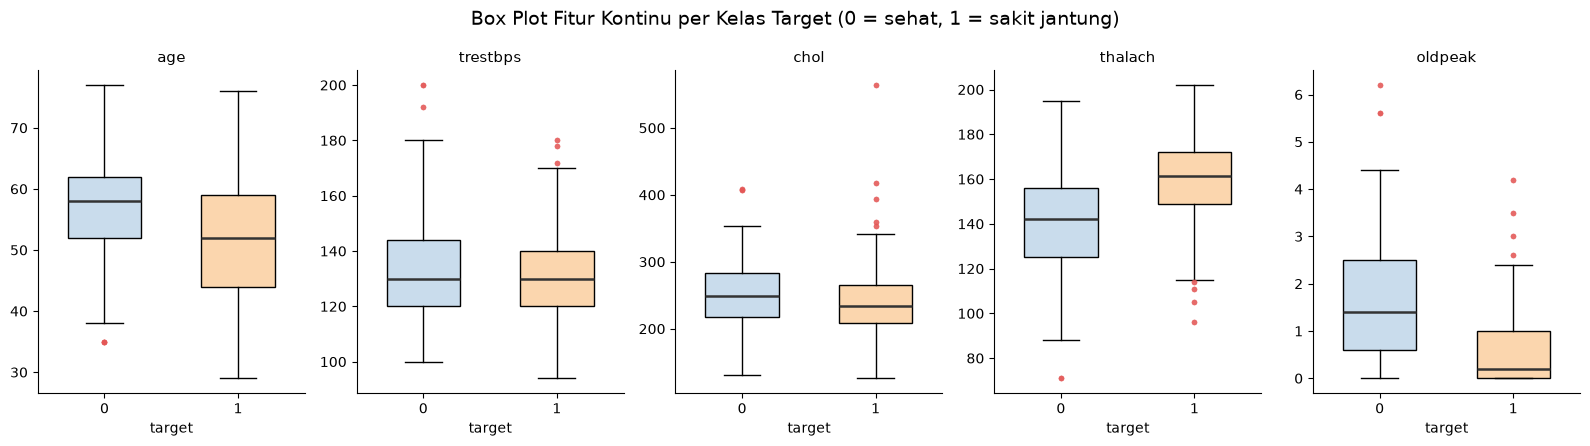

In [16]:
# guard: pastikan `data` tetap DataFrame
if not isinstance(globals().get("data"), pd.DataFrame):
    data = pd.read_csv("heart_disease_dataset.csv")

# fokus ke fitur numerik kontinu, dipisah per kelas target
kontinu = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

fig, axes = plt.subplots(1, len(kontinu), figsize=(16, 4.5))
axes = np.atleast_1d(axes).ravel()

for ax, col in zip(axes, kontinu):
    kelompok = [data.loc[data['target'] == t, col].dropna() for t in (0, 1)]
    bp = ax.boxplot(kelompok, widths=0.55, patch_artist=True,
                    medianprops=dict(color='#333', linewidth=1.8),
                    flierprops=dict(marker='o', markersize=4,
                                    markerfacecolor='#E45756', alpha=0.5,
                                    markeredgecolor='none'))
    for patch, warna in zip(bp['boxes'], ['#C9DCEC', '#FBD6AE']):
        patch.set_facecolor(warna)
    ax.set_xticks([1, 2])
    ax.set_xticklabels(['0', '1'])
    ax.set_title(col, fontsize=11)
    ax.set_xlabel('target')
    for sisi in ('top', 'right'):
        ax.spines[sisi].set_visible(False)

fig.suptitle('Box Plot Fitur Kontinu per Kelas Target (0 = sehat, 1 = sakit jantung)',
             fontsize=14)
plt.tight_layout()
plt.show()

### notes outlier
1. Box plot memakai aturan Tukey: nilai di luar Q1 - 1.5 x IQR atau Q3 + 1.5 x IQR dianggap outlier
2. Fitur kategorik (sex, cp, fbs, restecg, exang, slope, ca, thal, target) tetap ditampilkan untuk kelengkapan, tapi "outlier" di situ hanya berarti kategori yang jarang muncul, bukan nilai ekstrem
3. Outlier pada fitur kontinu (chol, trestbps, oldpeak) adalah yang paling layak dibahas karena berpengaruh ke Pearson - bandingkan dengan heatmap selisih Spearman - Pearson di atas
4. Jangan langsung dibuang: nilai ekstrem pada data medis sering justru kasus yang penting